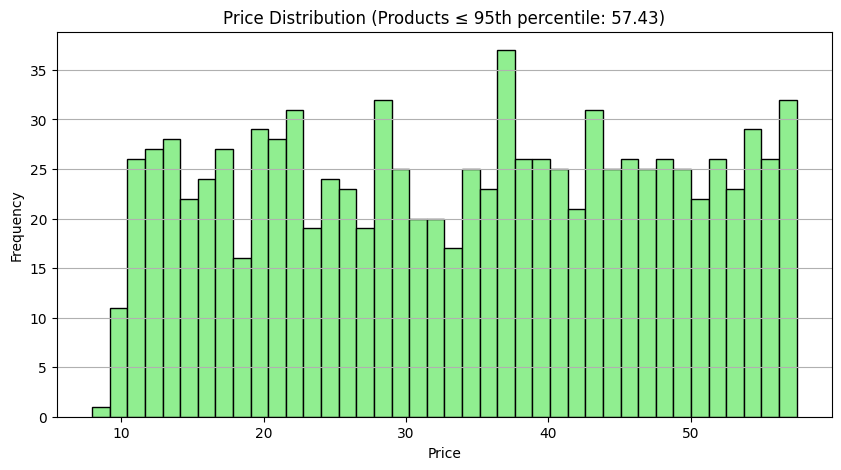

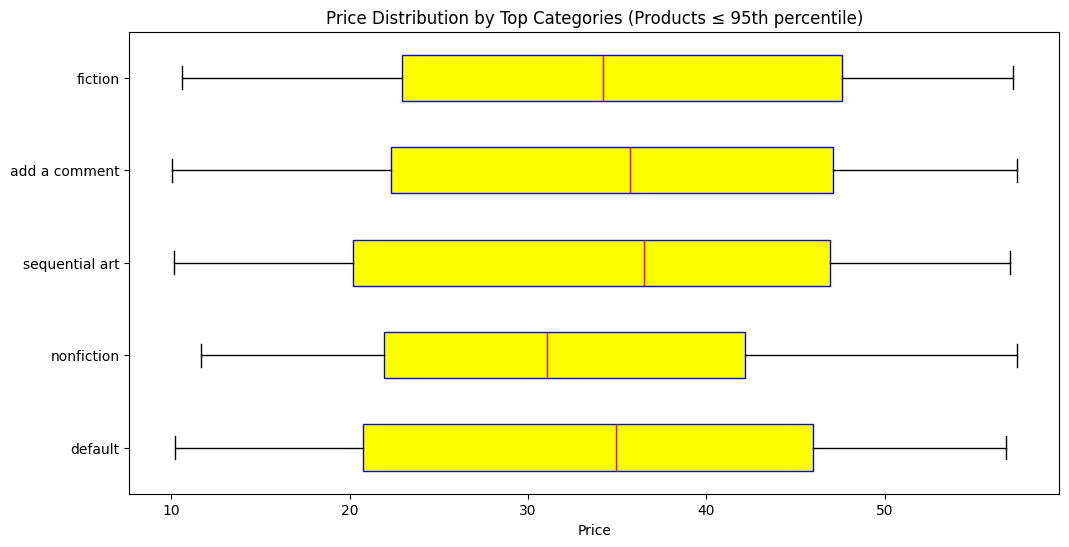

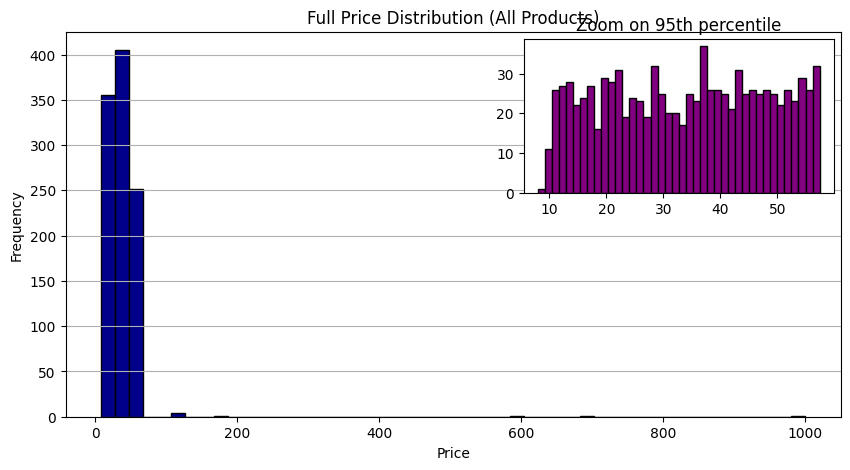

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
from sklearn.linear_model import LinearRegression
from sklearn.metrics.pairwise import cosine_similarity
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

#Price distribution histograms and box plots by category

# File path
CLEANED_CSV = '../data_processing/cleaned_book_data.csv'

# Load data
df = pd.read_csv(CLEANED_CSV)

# Filter out invalid prices
price_series = df['price'].dropna()
price_series = price_series[price_series > 0]

# Determine 95th percentile to focus on main cluster
price_95 = np.percentile(price_series, 95)

# Overall histogram
plt.figure(figsize=(10,5))
plt.hist(price_series[price_series <= price_95], bins=40, color='lightgreen', edgecolor='black')
plt.title(f'Price Distribution (Products ≤ 95th percentile: {price_95:.2f})')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.show()

# Boxplot by top 5 categories
top_cats = df['category'].value_counts().nlargest(5).index.tolist()
data_to_plot = [df.loc[(df['category']==cat) & (df['price']>0) & (df['price']<=price_95), 'price'].values for cat in top_cats]

plt.figure(figsize=(12,6))
plt.boxplot(data_to_plot, tick_labels=top_cats, vert=False, patch_artist=True,
            boxprops=dict(facecolor='yellow', color='blue'),
            medianprops=dict(color='red'))
plt.title(f'Price Distribution by Top Categories (Products ≤ 95th percentile)')
plt.xlabel('Price')
plt.show()

# Full range histogram with inset
plt.figure(figsize=(10,5))
plt.hist(price_series, bins=50, color='darkblue', edgecolor='black')
plt.title('Full Price Distribution (All Products)')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(axis='y')

# Inset focusing on main cluster
ax_inset = inset_axes(plt.gca(), width="40%", height="40%", loc=1)
ax_inset.hist(price_series[price_series <= price_95], bins=40, color='purple', edgecolor='black')
ax_inset.set_title('Zoom on 95th percentile')
plt.show()

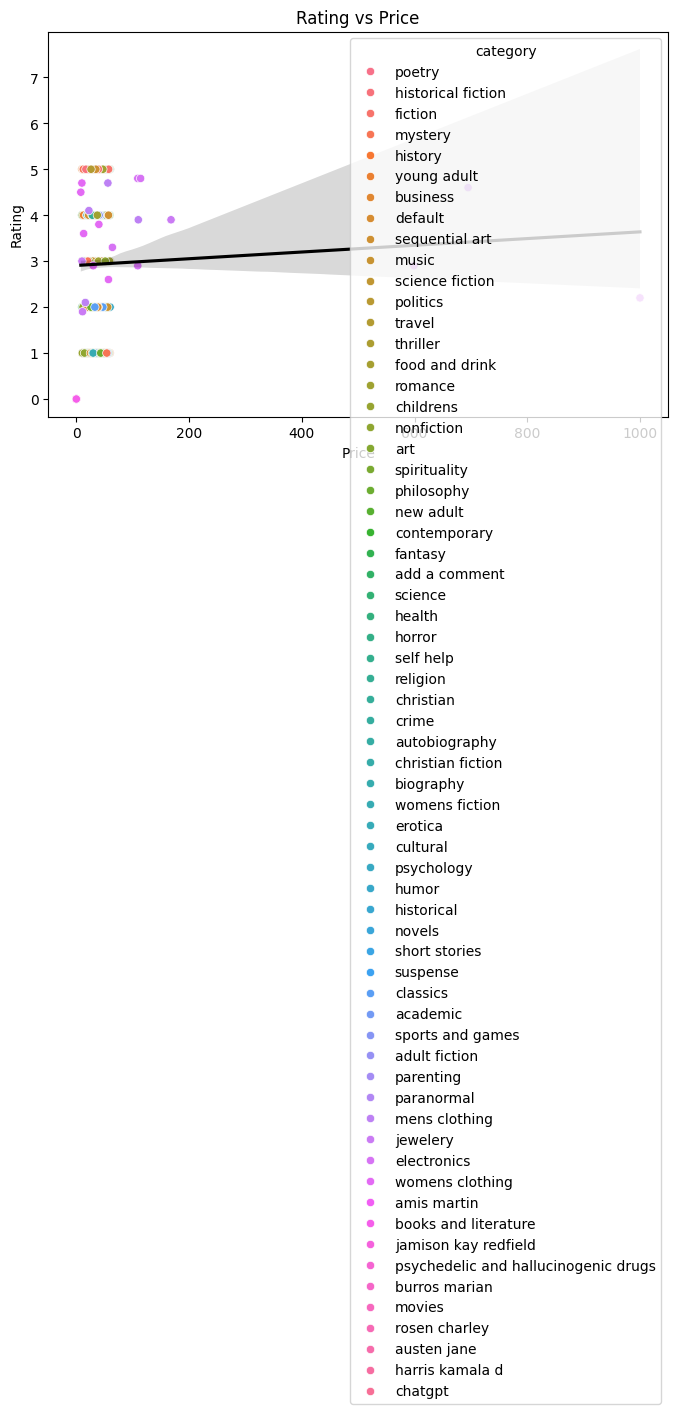

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='price', y='rating', hue='category')
sns.regplot(data=df[df['price']>0], x='price', y='rating', scatter=False, color='black')  # trend line
plt.title('Rating vs Price')
plt.xlabel('Price')
plt.ylabel('Rating')
plt.show()

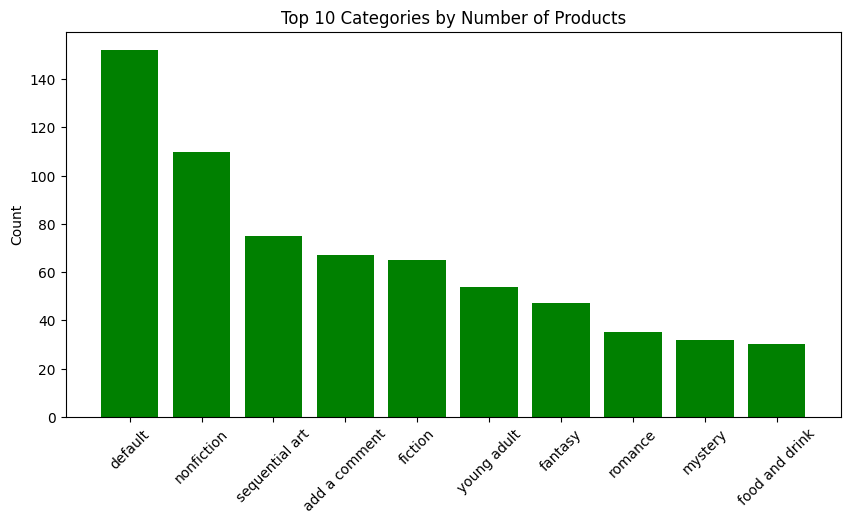

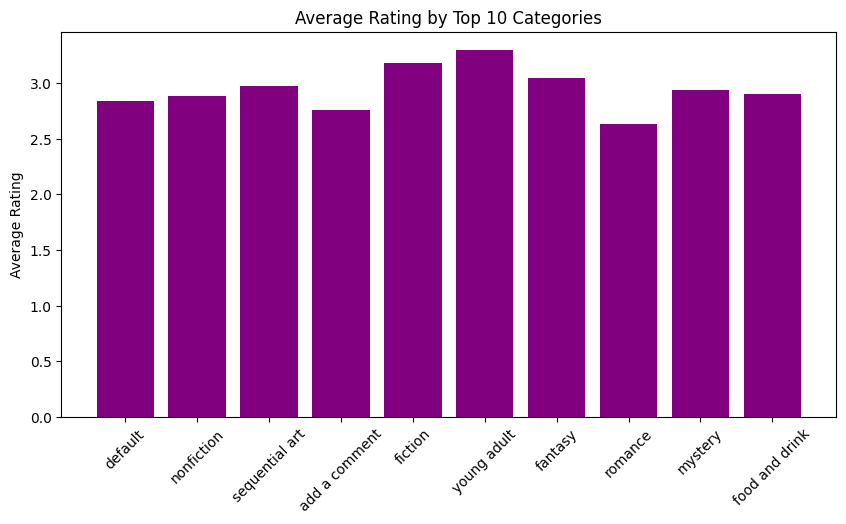

In [11]:
cat_summary = df.groupby('category').agg(
    count=('title','count'),
    avg_rating=('rating','mean')
).sort_values('count', ascending=False).head(10)

# Category popularity
plt.figure(figsize=(10,5))
plt.bar(cat_summary.index, cat_summary['count'], color='green')
plt.xticks(rotation=45)
plt.title('Top 10 Categories by Number of Products')
plt.ylabel('Count')
plt.show()

# Average rating
plt.figure(figsize=(10,5))
plt.bar(cat_summary.index, cat_summary['avg_rating'], color='purple')
plt.xticks(rotation=45)
plt.title('Average Rating by Top 10 Categories')
plt.ylabel('Average Rating')
plt.show()

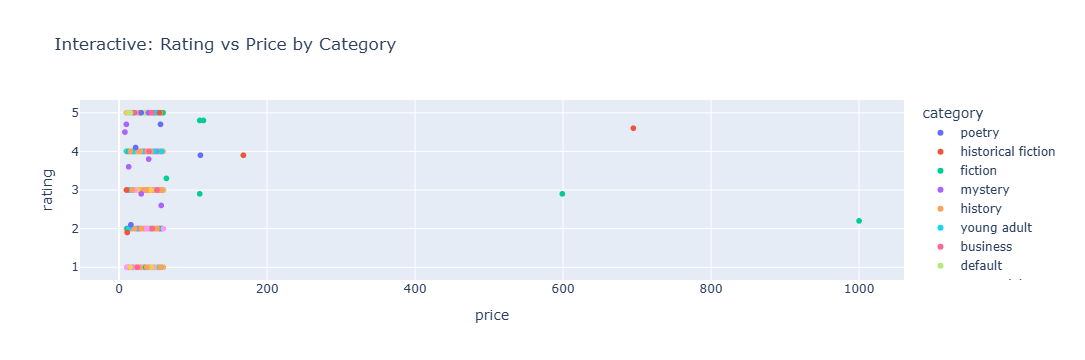

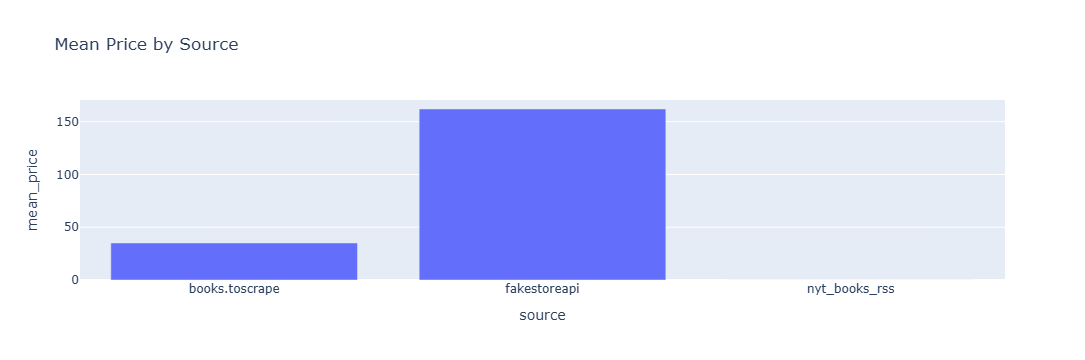

In [12]:
# Scatter: rating vs price colored by category
fig = px.scatter(
    df[df['price']>0],
    x='price',
    y='rating',
    color='category',
    hover_data=['title'],
    title='Interactive: Rating vs Price by Category'
)
fig.show()

# Bar chart: mean price by data source
source_summary = df.groupby('source').agg(mean_price=('price','mean')).reset_index()
fig2 = px.bar(source_summary, x='source', y='mean_price', title='Mean Price by Source')
fig2.show()

Intercept: 30.83, Coefficient: 1.99


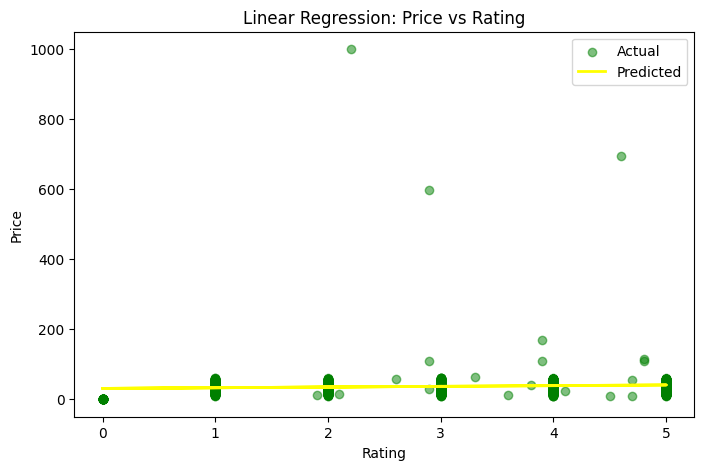

In [13]:
# Filter valid rows
reg_df = df[['price','rating']].dropna()
X = reg_df[['rating']].values
y = reg_df['price'].values

# Fit linear regression
model = LinearRegression()
model.fit(X, y)
print(f"Intercept: {model.intercept_:.2f}, Coefficient: {model.coef_[0]:.2f}")

# Predict
y_pred = model.predict(X)

# Plot
plt.figure(figsize=(8,5))
plt.scatter(X, y, color='green', alpha=0.5, label='Actual')
plt.plot(X, y_pred, color='yellow', linewidth=2, label='Predicted')
plt.xlabel('Rating')
plt.ylabel('Price')
plt.title('Linear Regression: Price vs Rating')
plt.legend()
plt.show()

In [14]:
category_prices = df.groupby('category')['price'].describe().sort_values('mean', ascending=False)
print(category_prices.head(10))

                  count        mean         std    min       25%      50%  \
category                                                                    
electronics         6.0  332.498333  383.745788  64.00  109.0000  111.500   
jewelery            4.0  220.995000  324.609725   9.99   10.7400   89.495   
suspense            1.0   58.330000         NaN  58.33   58.3300   58.330   
novels              1.0   54.810000         NaN  54.81   54.8100   54.810   
politics            3.0   53.613333    2.888119  51.33   51.9900   52.650   
health              4.0   51.452500    2.449005  49.05   49.5450   51.345   
mens clothing       4.0   51.057500   43.009222  15.99   20.7225   39.145   
new adult           6.0   46.383333    8.877600  36.29   40.4100   44.180   
christian           3.0   42.496667   14.822133  25.77   36.7450   47.720   
sports and games    5.0   41.166000   10.118724  24.42   40.4400   44.840   

                       75%     max  
category                            
e

In [15]:
# Cosine similarity based on price and rating

feature_df = df[['price','rating']].fillna(0)
similarity = cosine_similarity(feature_df)
print("Shape of similarity matrix:", similarity.shape)

# Example: Find 5 most similar products to the first row
most_similar_idx = np.argsort(similarity[0])[::-1][1:6]
print("Most similar products to first item:")
print(df.iloc[most_similar_idx][['title','price','rating']])

Shape of similarity matrix: (1049, 1049)
Most similar products to first item:
                                                 title  price  rating
157                                the genius of birds  17.24     1.0
517                                 raymie nightingale  34.41     2.0
904                                       when im gone  51.96     3.0
339                    angels  demons robert langdon 1  51.48     3.0
275  overload how to unplug unwind and unleash your...  52.15     3.0


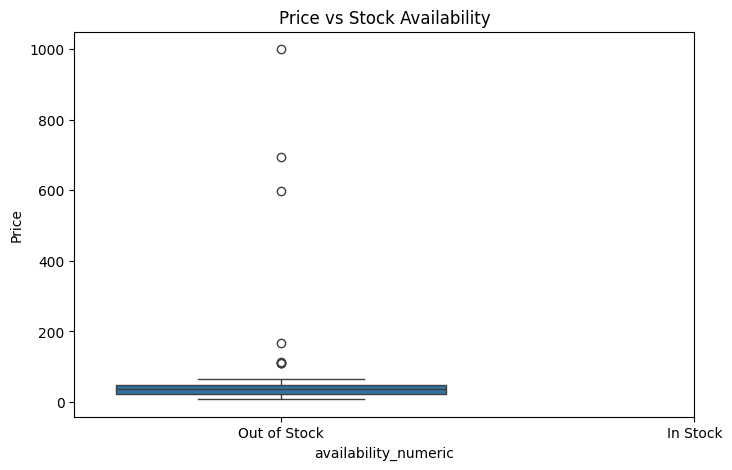

In [8]:
# Convert availability to numeric
df['availability_numeric'] = df['availability'].apply(lambda x: 1 if 'in stock' in str(x).lower() else 0)

plt.figure(figsize=(8,5))
sns.boxplot(x='availability_numeric', y='price', data=df[df['price']>0])
plt.xticks([0,1], ['Out of Stock','In Stock'])
plt.ylabel('Price')
plt.title('Price vs Stock Availability')
plt.show()